In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression


In [2]:
df_healtRisk=pd.read_csv("D:\לימודים יד\בינה מלאכותית\שב\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset (1).csv")

<>:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
<>:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
C:\Users\dassi\AppData\Local\Temp\ipykernel_25716\31050540.py:1: SyntaxWarning: "\L" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\L"? A raw string is also an option.
  df_healtRisk=pd.read_csv("D:\לימודים יד\בינה מלאכותית\שב\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset (1).csv")


In [3]:
df_healtRisk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [4]:
df_healtRisk.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [5]:
df_healtRisk.isnull().sum()

age             0
weight          0
height          0
exercise        0
sleep           0
sugar_intake    0
smoking         0
alcohol         0
married         0
profession      0
bmi             0
health_risk     0
dtype: int64

In [6]:
df_healtRisk.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [7]:
# sns.barplot(x='sugar_intake',y='bmi', data=df_healtRisk)

<Axes: xlabel='bmi', ylabel='Count'>

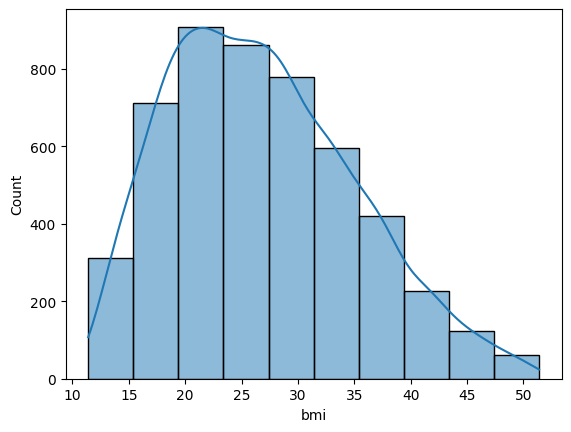

In [8]:
sns.histplot(x='bmi',data=df_healtRisk,bins=10,kde=True)

<Axes: xlabel='bmi', ylabel='health_risk'>

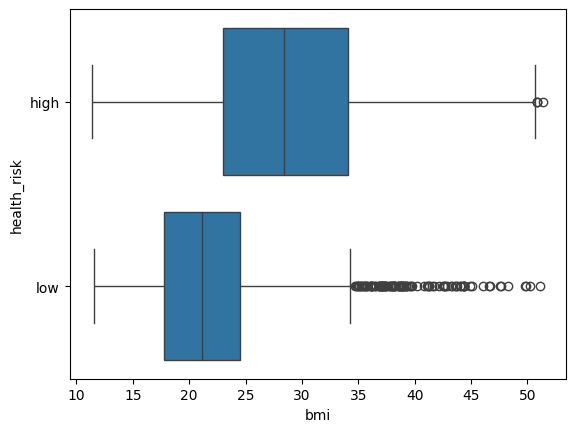

In [9]:
sns.boxplot(x='bmi',y='health_risk', data=df_healtRisk)

<Axes: xlabel='sleep', ylabel='health_risk'>

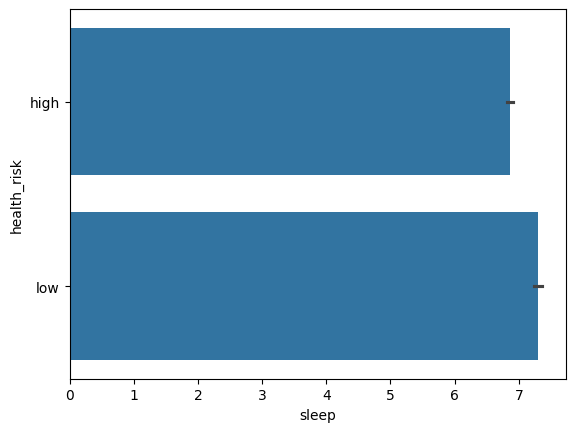

In [10]:
sns.barplot(x='sleep',y='health_risk', data=df_healtRisk)

<Axes: xlabel='smoking', ylabel='count'>

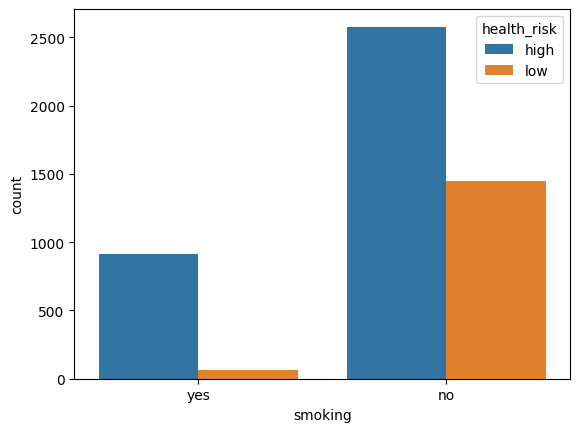

In [11]:
sns.countplot(x='smoking', hue='health_risk', data=df_healtRisk)

<Axes: xlabel='alcohol', ylabel='health_risk'>

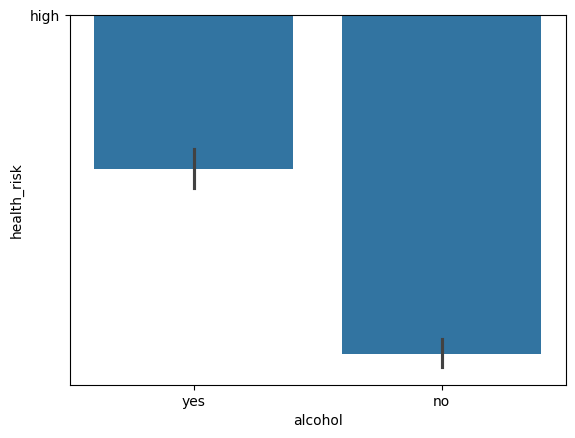

In [12]:
sns.barplot(x='alcohol', y='health_risk', data=df_healtRisk)

<Axes: xlabel='age', ylabel='bmi'>

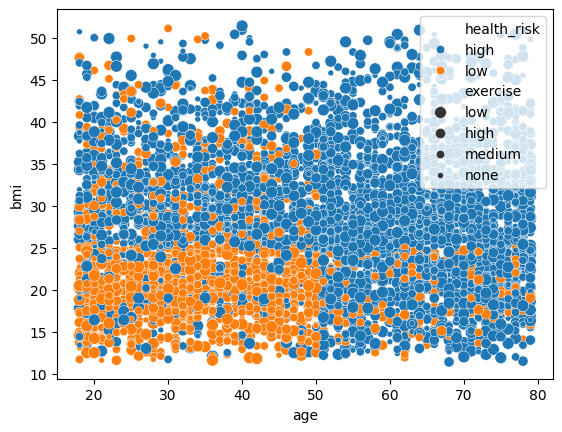

In [13]:
sns.scatterplot(x='age',y='bmi', size='exercise',hue='health_risk', data=df_healtRisk)

#עבודת הנרמולים:

In [14]:
#הוספת עמודה של צריכה כפולה של חומרים ממכרים

df_healtRisk['dual_substance_use']=0
dual_use_condition=(df_healtRisk['smoking']=='yes')&(df_healtRisk['alcohol']=='yes')
df_healtRisk.loc[dual_use_condition,'dual_substance_use']=1

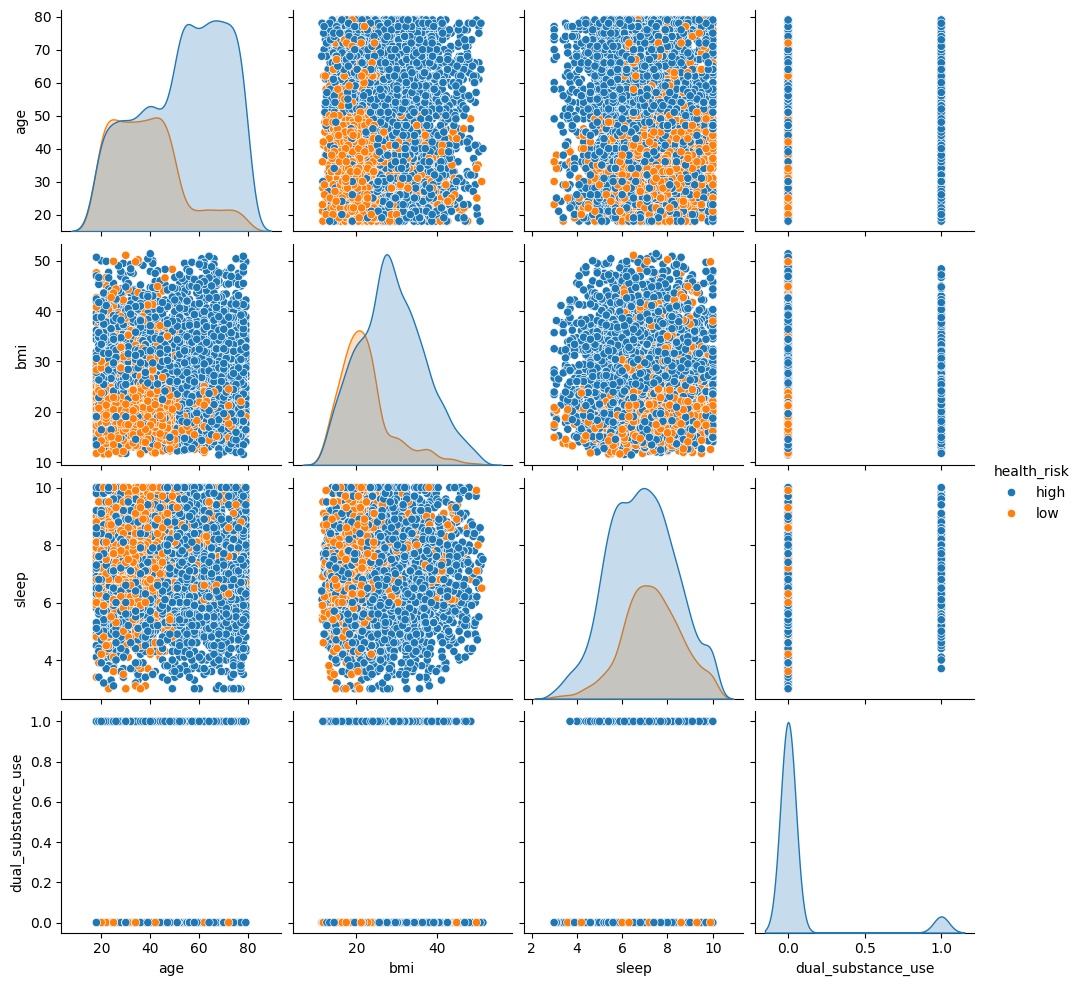

In [15]:
#בדיקת הזוגות- להתאמת רגרסיה לוגיסטית()אחרי הוספת העמודה החדשה

cols_to_plot = ['age', 'bmi', 'sleep', 'dual_substance_use', 'health_risk']
sns.pairplot(data=df_healtRisk[cols_to_plot], hue='health_risk', diag_kind='kde')


In [16]:
print(df_healtRisk[['smoking', 'alcohol', 'dual_substance_use']].head(10))

print("\nהתפלגות משתמשים כפולים בדאטה סט:")
print(df_healtRisk['dual_substance_use'].value_counts())

  smoking alcohol  dual_substance_use
0     yes     yes                   1
1      no      no                   0
2     yes      no                   0
3      no      no                   0
4      no      no                   0
5      no      no                   0
6      no      no                   0
7     yes      no                   0
8      no      no                   0
9     yes      no                   0

התפלגות משתמשים כפולים בדאטה סט:
dual_substance_use
0    4751
1     249
Name: count, dtype: int64


In [17]:
df_processed = df_healtRisk.drop(columns=['weight', 'height','married'])

In [18]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 5000 non-null   int64  
 1   exercise            5000 non-null   object 
 2   sleep               5000 non-null   float64
 3   sugar_intake        5000 non-null   object 
 4   smoking             5000 non-null   object 
 5   alcohol             5000 non-null   object 
 6   profession          5000 non-null   object 
 7   bmi                 5000 non-null   float64
 8   health_risk         5000 non-null   object 
 9   dual_substance_use  5000 non-null   int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 390.8+ KB


In [19]:
X = df_processed.drop(columns=['health_risk'])
y = df_processed['health_risk'].map({'low': 0, 'high': 1})
print(X.shape)
print(y.shape)

(5000, 9)
(5000,)


In [20]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numerical_cols)


['age', 'sleep', 'bmi', 'dual_substance_use']


In [21]:
categorical_cols=X.select_dtypes(include=['object']).columns.tolist()
print(categorical_cols)

['exercise', 'sugar_intake', 'smoking', 'alcohol', 'profession']


In [22]:
scaler=MinMaxScaler()
X_numerical_scaled = pd.DataFrame(
    scaler.fit_transform(X[numerical_cols]), 
    columns=numerical_cols
)
X_numerical_scaled.reset_index(drop=True, inplace=True)

print(X_numerical_scaled)

           age     sleep     bmi  dual_substance_use
0     0.622951  0.442857  0.1550                 1.0
1     0.836066  0.557143  0.3725                 0.0
2     0.459016  0.514286  0.8475                 0.0
3     0.229508  0.785714  0.1050                 0.0
4     0.688525  0.714286  0.3600                 0.0
...        ...       ...     ...                 ...
4995  0.393443  0.600000  0.2500                 0.0
4996  0.344262  0.628571  0.3575                 0.0
4997  0.491803  0.600000  0.0875                 1.0
4998  0.262295  0.985714  0.9600                 0.0
4999  0.885246  0.471429  0.2450                 0.0

[5000 rows x 4 columns]


In [23]:
X_categorical_encoded = pd.get_dummies(
    df_processed[categorical_cols], 
    drop_first=False 
).astype(int)
X_categorical_encoded.reset_index(drop=True, inplace=True)

print(X_categorical_encoded.head())

   exercise_high  exercise_low  exercise_medium  exercise_none  \
0              0             1                0              0   
1              1             0                0              0   
2              1             0                0              0   
3              0             0                1              0   
4              1             0                0              0   

   sugar_intake_high  sugar_intake_low  sugar_intake_medium  smoking_no  \
0                  0                 0                    1           0   
1                  1                 0                    0           1   
2                  0                 1                    0           0   
3                  0                 0                    1           1   
4                  0                 1                    0           1   

   smoking_yes  alcohol_no  alcohol_yes  profession_artist  profession_doctor  \
0            1           0            1                  0             

In [24]:
X_final = pd.concat([X_numerical_scaled, X_categorical_encoded], axis=1)
print(X_final)

           age     sleep     bmi  dual_substance_use  exercise_high  \
0     0.622951  0.442857  0.1550                 1.0              0   
1     0.836066  0.557143  0.3725                 0.0              1   
2     0.459016  0.514286  0.8475                 0.0              1   
3     0.229508  0.785714  0.1050                 0.0              0   
4     0.688525  0.714286  0.3600                 0.0              1   
...        ...       ...     ...                 ...            ...   
4995  0.393443  0.600000  0.2500                 0.0              0   
4996  0.344262  0.628571  0.3575                 0.0              0   
4997  0.491803  0.600000  0.0875                 1.0              0   
4998  0.262295  0.985714  0.9600                 0.0              0   
4999  0.885246  0.471429  0.2450                 0.0              1   

      exercise_low  exercise_medium  exercise_none  sugar_intake_high  \
0                1                0              0                  0   
1

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 23)
(1000, 23)
(4000,)
(1000,)


In [26]:
N=10
knn = KNeighborsClassifier(n_neighbors=N)
knn.fit(X_train,y_train)

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None



--- Y_pred (חזוי) ---
 [1 0 0 1 1 1 1 0 1 1]

--- Y_test (אמיתי) ---
 [1 0 0 1 1 1 1 0 0 1]


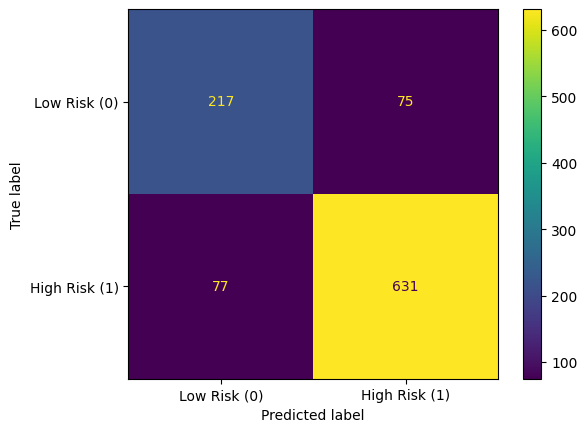

In [27]:
y_pred=knn.predict(X_test)

print("\n--- Y_pred (חזוי) ---\n", y_pred[:N])
print("\n--- Y_test (אמיתי) ---\n", y_test.head(N).values)

display_labels = ['Low Risk (0)', 'High Risk (1)'] 
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=display_labels
).plot()


In [28]:
# print("\n--- דוח סיווג (Classification Report) ---")
print(classification_report(y_test, y_pred, target_names=display_labels))

               precision    recall  f1-score   support

 Low Risk (0)       0.74      0.74      0.74       292
High Risk (1)       0.89      0.89      0.89       708

     accuracy                           0.85      1000
    macro avg       0.82      0.82      0.82      1000
 weighted avg       0.85      0.85      0.85      1000



In [29]:
log_reg = LogisticRegression(random_state=42, solver='liblinear') 
log_reg.fit(X_train, y_train)

# 2. הצגת המקדמים (המשקולות W)
coefficients = log_reg.coef_[0]
feature_names = X_train.columns
intercept = log_reg.intercept_[0]

print("--- מקדמי רגרסיה לוגיסטית (חשיבות התכונות) ---")
for name, coef in zip(feature_names, coefficients):
    print(f"מקדם {name}: {coef:.4f}")

print(f"\nאיבר חופשי (Intercept): {intercept:.4f}")

--- מקדמי רגרסיה לוגיסטית (חשיבות התכונות) ---
מקדם age: 6.3283
מקדם sleep: -2.9334
מקדם bmi: 9.1588
מקדם dual_substance_use: 1.0883
מקדם exercise_high: -1.3185
מקדם exercise_low: 1.1827
מקדם exercise_medium: -1.3239
מקדם exercise_none: 1.2495
מקדם sugar_intake_high: 1.3815
מקדם sugar_intake_low: -0.7693
מקדם sugar_intake_medium: -0.8224
מקדם smoking_no: -2.0699
מקדם smoking_yes: 1.8597
מקדם alcohol_no: -1.2287
מקדם alcohol_yes: 1.0185
מקדם profession_artist: -0.1090
מקדם profession_doctor: -0.0611
מקדם profession_driver: 0.1478
מקדם profession_engineer: 0.0756
מקדם profession_farmer: -0.0261
מקדם profession_office_worker: -0.1297
מקדם profession_student: 0.0380
מקדם profession_teacher: -0.1457

איבר חופשי (Intercept): -0.2102


In [30]:
solver='liblinear'
# חיזוי על נתוני הבדיקה
y_pred_lr = log_reg.predict(X_test)
print("\n--- דוח סיווג (Classification Report) - רגרסיה לוגיסטית ---\n")
print(classification_report(y_test, y_pred_lr, target_names=['Low Risk (0)', 'High Risk (1)']))



--- דוח סיווג (Classification Report) - רגרסיה לוגיסטית ---

               precision    recall  f1-score   support

 Low Risk (0)       0.81      0.76      0.78       292
High Risk (1)       0.90      0.93      0.91       708

     accuracy                           0.88      1000
    macro avg       0.85      0.84      0.85      1000
 weighted avg       0.87      0.88      0.87      1000

